In [1]:
from typing import LiteralString
!pip install numpy pandas matplotlib seaborn nltk scikit-learn
!pip install gensim tensorflow keras transformers torch
!pip install datasets # for MIDB from HuggingFace

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.4 MB/s eta 0:00:00


In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

train_data = dataset["train"].to_pandas()
test_data  = dataset["test"].to_pandas()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
print(train_data.shape)

(25000, 2)


In [4]:
print(train_data.head())
print(train_data["label"].value_counts())


                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
label
0    12500
1    12500
Name: count, dtype: int64


In [5]:
print(test_data.head())

                                                text  label
0  I love sci-fi and am willing to put up with a ...      0
1  Worth the entertainment value of a rental, esp...      0
2  its a totally average film with a few semi-alr...      0
3  STAR RATING: ***** Saturday Night **** Friday ...      0
4  First off let me say, If you haven't enjoyed a...      0


In [6]:
print(train_data.isnull().sum())

text     0
label    0
dtype: int64


In [7]:
test_data.isnull().sum()


,0
text,0
label,0


In [8]:
test_data.describe()

,label
count,25000.00000
mean,0.50000
std,0.50001
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


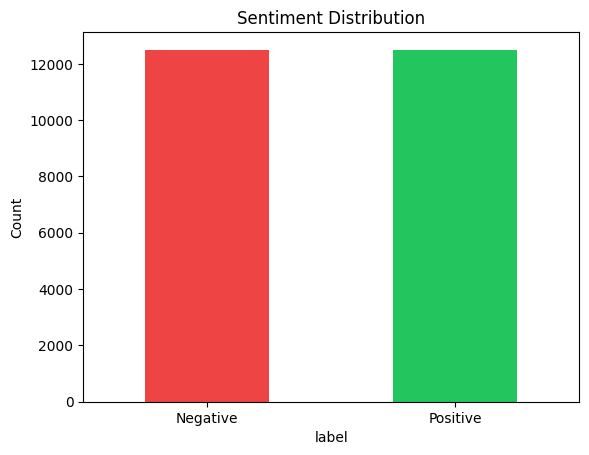

In [9]:
import matplotlib.pyplot as plt

train_data["label"].value_counts().plot(kind="bar",
    color=["#ef4444","#22c55e"])
plt.title("Sentiment Distribution")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)
plt.ylabel("Count")
plt.show()

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: length, dtype: float64


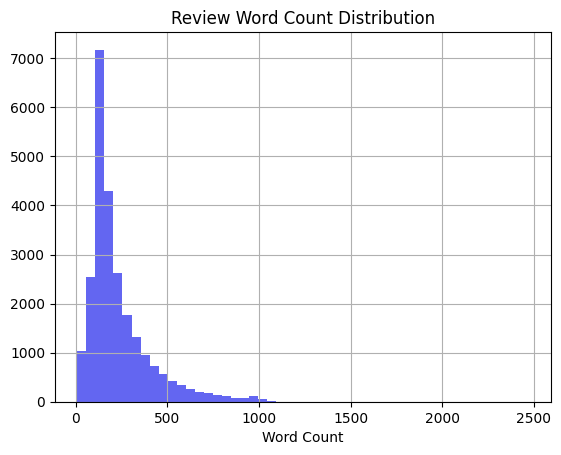

In [10]:
#Review analysis

train_data["length"] = train_data["text"].apply(lambda x: len(x.split()))

print(train_data["length"].describe())

train_data["length"].hist(bins=50, color="#6366f1")
plt.title("Review Word Count Distribution")
plt.xlabel("Word Count")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


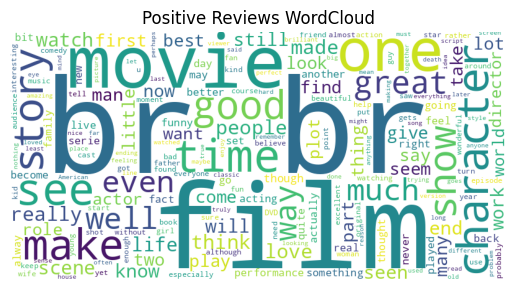

In [11]:
# Wordcloud
!pip install wordcloud

from wordcloud import WordCloud

positive = " ".join(train_data[train_data["label"]==1]["text"])
import nltk
nltk.download("stopwords")
nltk.download("punkt")

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

stop_words  = set(stopwords.words("english"))
stemmer     = SnowballStemmer("english")
# WordCloud(width=800, height=400, background_color="white").generate(positive)
# plt.imshow(plt.imread)

wc = WordCloud(width=800, height=400, background_color="white").generate(positive)
plt.imshow(wc)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

In [12]:
# nltk resouces

import nltk
nltk.download("stopwords")
nltk.download("punkt")

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

stop_words  = set(stopwords.words("english"))
stemmer     = SnowballStemmer("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [13]:
import re
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer() # Initialize lemmatizer globally if used in preprocess

def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # Contraction replacements
    text = text.replace("n't", " not")
    text = text.replace("won't", "will not")
    text = text.replace("can't", "cannot")

    # URL removal
    text = re.sub(r"http\S+|www\S+", "", text)

    # 2. Remove HTML tags (IMDB has <br /> tags)
    text = re.sub(r"<.*?>", " ", text)
    # 3. Remove special characters & numbers
    text = re.sub(r"[^a-z\s]", "", text)
    # 4. Tokenize
    tokens = text.split()
    # 5. Remove stopwords +  lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    # Whitespace normalization
    text = re.sub(r"\s+", " ", " ".join(tokens)).strip()

    return text

train_data["clean"] = train_data["text"].apply(preprocess)
test_data["clean"]  = test_data["text"].apply(preprocess)
print(train_data["clean"].head(3))

[nltk_data] Downloading package wordnet to /root/nltk_data...


0    rented curiousyellow video store controversy s...
1    curious yellow risible pretentious steaming pi...
2    avoid making type film future film interesting...
Name: clean, dtype: object


In [14]:
train_data["clean"].replace("", float("nan"), inplace=True)
train_data.dropna(subset=["clean"], inplace=True)
print("Remaining rows:", len(train_data))

Remaining rows: 25000


/tmp/ipykernel_1141/1017156647.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data["clean"].replace("", float("nan"), inplace=True)


In [15]:
train_data.to_csv("train_clean.csv", index=False)
test_data.to_csv("test_clean.csv", index=False)
print("Saved!")

Saved!


In [16]:
# Vectorization

# TF- IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(train_data["clean"])
X_test_tfidf  = tfidf.transform(test_data["clean"])

y_train = train_data["label"]
y_test  = test_data["label"]

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (25000, 10000)


In [17]:
# Word2Vec Embeddings

from gensim.models import Word2Vec

# Tokenize for Word2Vec
sentences = [text.split() for text in train_data["clean"]]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # 100-dim embeddings
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print("Vocab size:", len(w2v_model.wv))
print("Vector for 'great':", w2v_model.wv["great"][:5])

Vocab size: 46525
Vector for 'great': [-0.43627954  1.2503548  -2.122592    1.649299    0.18375176]


In [18]:
# Find most similar words to common sentiment words
for word in ["good", "bad", "great", "terrible"]:
    similar = w2v_model.wv.most_similar(word, topn=5)
    print(f"\nWords similar to '{word}':")
    for w, score in similar:
        print(f"  {w:<15} {score:.4f}")


Words similar to 'good':
  decent          0.7453
  great           0.7107
  bad             0.6859
  excellent       0.6446
  nice            0.6219

Words similar to 'bad':
  awful           0.7151
  terrible        0.7021
  good            0.6859
  horrible        0.6504
  suck            0.6475

Words similar to 'great':
  fantastic       0.7292
  wonderful       0.7231
  excellent       0.7124
  good            0.7107
  fine            0.6747

Words similar to 'terrible':
  horrible        0.8578
  awful           0.8019
  atrocious       0.7695
  dreadful        0.7301
  abysmal         0.7299


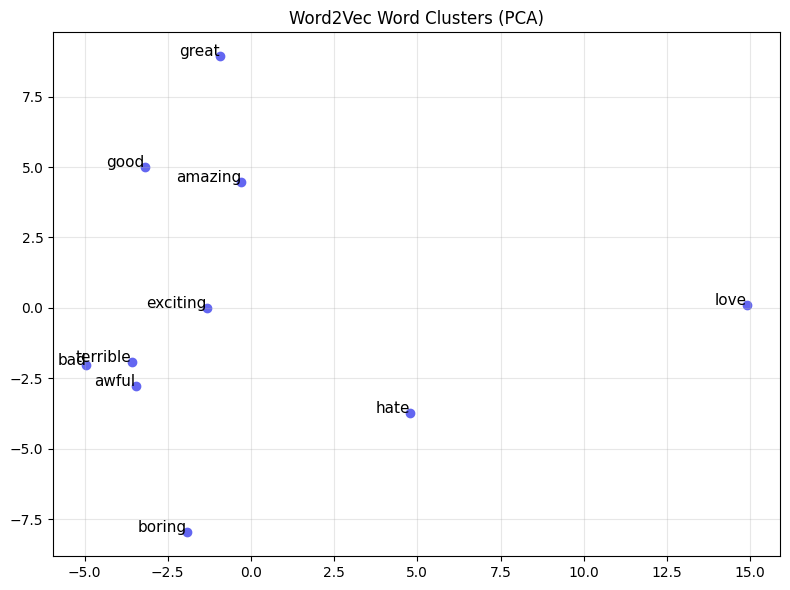

In [19]:
#Visualize word2Vec with PCA

from sklearn.decomposition import PCA

words = ["good","bad","great","terrible",
         "love","hate","boring","exciting",
         "awful","amazing"]

vectors = [w2v_model.wv[w] for w in words]

pca    = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(coords[i,0], coords[i,1], color="#6366f1")
    plt.annotate(word, (coords[i,0], coords[i,1]),
                 fontsize=11, ha="right")
plt.title("Word2Vec Word Clusters (PCA)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

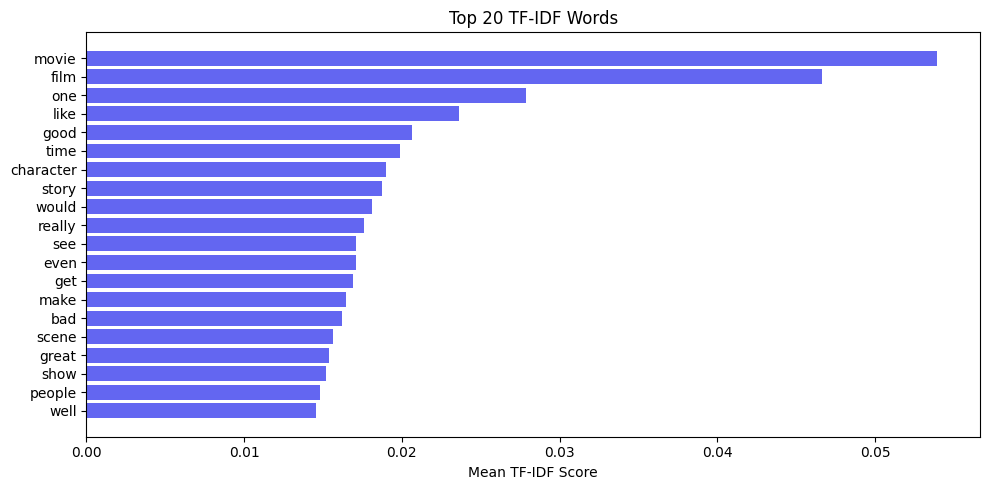

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Get top 20 most important TF-IDF words
feature_names = tfidf.get_feature_names_out()
tfidf_scores  = X_train_tfidf.mean(axis=0).A1

top_indices = tfidf_scores.argsort()[-20:][::-1]
top_words   = [feature_names[i] for i in top_indices]
top_scores  = [tfidf_scores[i] for i in top_indices]

plt.figure(figsize=(10,5))
plt.barh(top_words[::-1], top_scores[::-1], color="#6366f1")
plt.title("Top 20 TF-IDF Words")
plt.xlabel("Mean TF-IDF Score")
plt.tight_layout()
plt.show()

In [21]:
sparsity = 1 - (X_train_tfidf.nnz /
          (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))
print(f"TF-IDF Matrix Sparsity: {sparsity:.2%}")


TF-IDF Matrix Sparsity: 99.06%


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

# Naive Bayes model
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb,
      target_names=["Negative", "Positive"]))

'''cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg","Pos"],
            yticklabels=["Neg","Pos"])
plt.title("Naive Bayes — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()'''

Naive Bayes Accuracy: 0.85292
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.85     12500
    Positive       0.86      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



'cm = confusion_matrix(y_test, y_pred_nb)\nsns.heatmap(cm, annot=True, fmt="d", cmap="Blues",\n            xticklabels=["Neg","Pos"],\n            yticklabels=["Neg","Pos"])\nplt.title("Naive Bayes — Confusion Matrix")\nplt.ylabel("Actual"); plt.xlabel("Predicted")\nplt.tight_layout(); plt.show()'

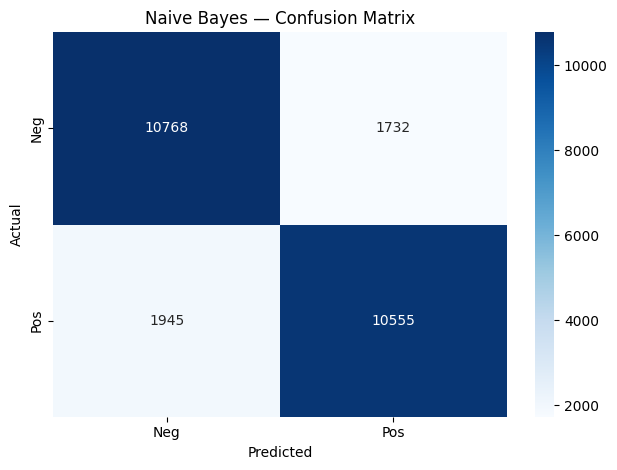

In [27]:

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neg","Pos"],
            yticklabels=["Neg","Pos"])
plt.title("Naive Bayes — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

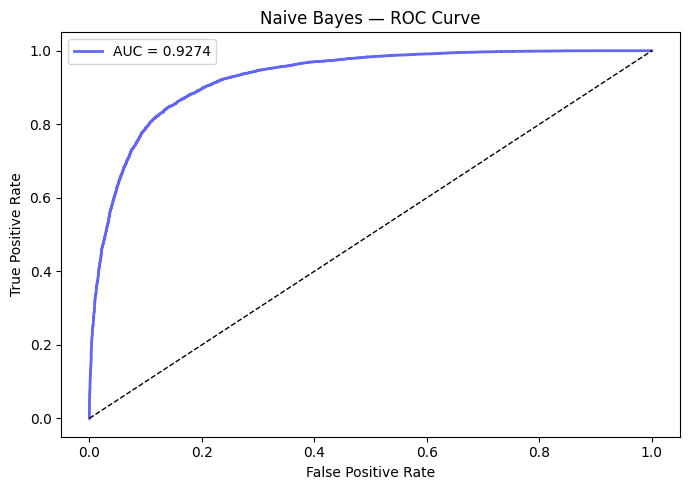

In [28]:
#ROC curve

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#6366f1", lw=2,
         label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
feature_names = tfidf.get_feature_names_out()
log_probs = nb_model.feature_log_prob_

top_neg = log_probs[0].argsort()[-15:][::-1]
top_pos = log_probs[1].argsort()[-15:][::-1]

print("Top Negative Words:")
print([feature_names[i] for i in top_neg])

print("\nTop Positive Words:")
print([feature_names[i] for i in top_pos])

Top Negative Words:
['movie', 'film', 'one', 'like', 'bad', 'even', 'would', 'good', 'time', 'character', 'really', 'get', 'make', 'could', 'scene']

Top Positive Words:
['film', 'movie', 'one', 'great', 'story', 'like', 'good', 'time', 'character', 'see', 'well', 'show', 'love', 'really', 'also']


In [30]:
from sklearn.model_selection import cross_val_score

alphas = [0.01, 0.05, 0.1, 0.5, 1.0]
scores = []

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    score = cross_val_score(model, X_train_tfidf,
                            y_train, cv=5,
                            scoring="accuracy").mean()
    scores.append(score)
    print(f"Alpha {alpha:.2f} → {score:.4f}")

best_alpha = alphas[scores.index(max(scores))]
print(f"\nBest Alpha: {best_alpha}")

Alpha 0.01 → 0.8134
Alpha 0.05 → 0.8170
Alpha 0.10 → 0.8191
Alpha 0.50 → 0.8275
Alpha 1.00 → 0.8320

Best Alpha: 1.0


In [31]:
# reviews
my_reviews = [
    "This movie was absolutely fantastic!",
    "Terrible plot, worst film I have ever seen.",
    "It was okay, nothing special."
]

cleaned   = [preprocess(r) for r in my_reviews]
vectorized = tfidf.transform(cleaned)
preds      = nb_model.predict(vectorized)
probs      = nb_model.predict_proba(vectorized)

for review, pred, prob in zip(my_reviews, preds, probs):
    label = "Positive" if pred == 1 else "Negative"
    print(f"\nReview : {review}")
    print(f"Prediction : {label}")
    print(f"Confidence : {max(prob):.2%}")


Review : This movie was absolutely fantastic!
Prediction : Positive
Confidence : 54.14%

Review : Terrible plot, worst film I have ever seen.
Prediction : Negative
Confidence : 98.08%

Review : It was okay, nothing special.
Prediction : Negative
Confidence : 82.03%


###LSTM Model

In [37]:
# LSTM
#Prepare Sequences for LSTM
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN   = 200
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_data["clean"])

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(train_data["clean"]),
    maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq  = pad_sequences(
    tokenizer.texts_to_sequences(test_data["clean"]),
    maxlen=MAX_LEN, padding="post", truncating="post")

# Build embedding matrix from Word2Vec
word_index = tokenizer.word_index
EMBED_DIM  = 100
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
for word, i in word_index.items():
    if i < VOCAB_SIZE and word in w2v_model.wv:
        embed_matrix[i] = w2v_model.wv[word]

In [33]:
#Build & Train LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense,
                                     Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM,
              weights=[embed_matrix], trainable=False, # true for more accuracy
              input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(optimizer="adam",
                   loss="binary_crossentropy",
                   metrics=["accuracy"])
model_lstm.summary()

es = EarlyStopping(patience=2, restore_best_weights=True)
history = model_lstm.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=10, batch_size=64,
    callbacks=[es]
)

loss, acc = model_lstm.evaluate(X_test_seq, y_test)
print(f"LSTM Test Accuracy: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.7862 - loss: 0.4652 - val_accuracy: 0.8212 - val_loss: 0.4634
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8371 - loss: 0.3876 - val_accuracy: 0.7596 - val_loss: 0.5915
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8596 - loss: 0.3343 - val_accuracy: 0.8516 - val_loss: 0.3827
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8543 - loss: 0.3436 - val_accuracy: 0.8724 - val_loss: 0.3689
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8667 - loss: 0.3204 - val_accuracy: 0.8768 - val_loss: 0.3495
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8839 - loss: 0.2849 - val_accuracy: 0.7772 - val_loss: 0.4931
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8986 - loss: 0.2527 - val_accuracy: 0.8300 - val_loss: 0.3869
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8624 - loss: 0.3198
LSTM Test Acc

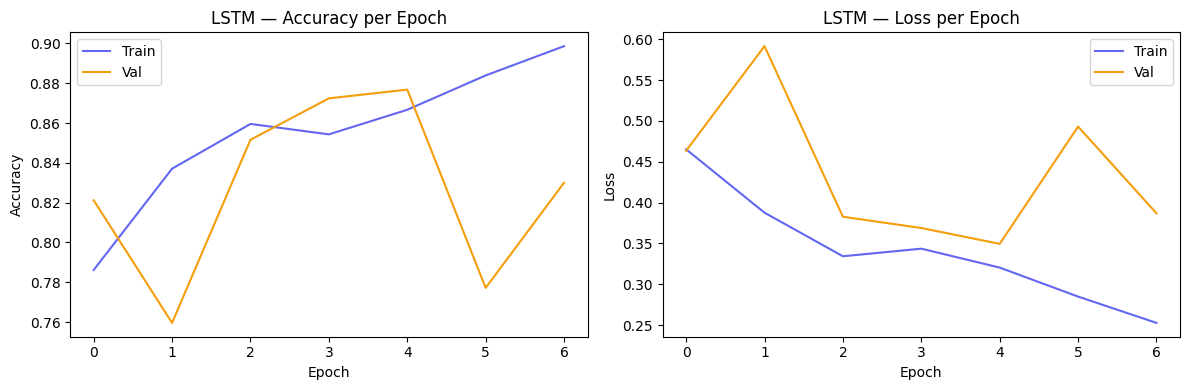

In [34]:
# plot training history

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train", color="#6366f1")
plt.plot(history.history["val_accuracy"], label="Val", color="#f59e0b")
plt.title("LSTM — Accuracy per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train", color="#6366f1")
plt.plot(history.history["val_loss"], label="Val", color="#f59e0b")
plt.title("LSTM — Loss per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
y_pred_lstm_prob = model_lstm.predict(X_test_seq)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm,
      target_names=["Negative","Positive"]))

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86     12500
    Positive       0.85      0.89      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step


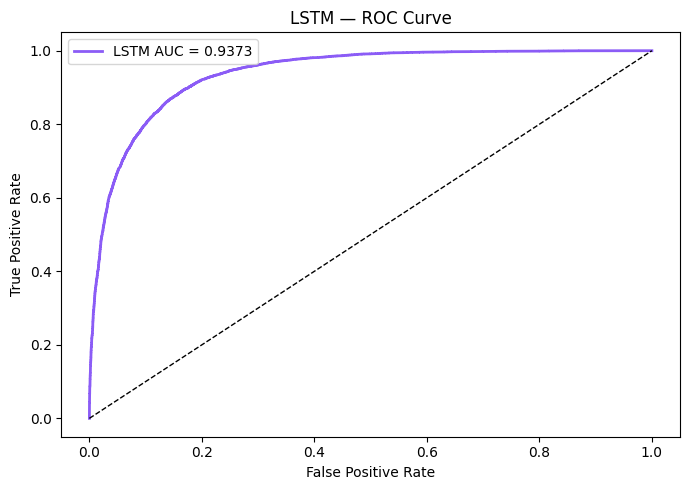

In [38]:
# roc curve

y_prob_lstm = model_lstm.predict(X_test_seq).flatten()
fpr, tpr, _ = roc_curve(y_test, y_prob_lstm)
auc = roc_auc_score(y_test, y_prob_lstm)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#8b5cf6", lw=2,
         label=f"LSTM AUC = {auc:.4f}")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.title("LSTM — ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout(); plt.show()

In [39]:
# custom review

my_reviews = [
    "This movie was absolutely fantastic!",
    "Terrible plot, worst film I have ever seen.",
    "It was okay, nothing special."
]

cleaned = [preprocess(r) for r in my_reviews]
seqs = pad_sequences(
    tokenizer.texts_to_sequences(cleaned),
    maxlen=MAX_LEN, padding="post")

probs = model_lstm.predict(seqs).flatten()

for review, prob in zip(my_reviews, probs):
    label = "Positive" if prob > 0.5 else "Negative"
    print(f"\nReview    : {review}")
    print(f"Prediction: {label}")
    print(f"Confidence: {max(prob, 1-prob):.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Review    : This movie was absolutely fantastic!
Prediction: Positive
Confidence: 98.03%

Review    : Terrible plot, worst film I have ever seen.
Prediction: Negative
Confidence: 98.61%

Review    : It was okay, nothing special.
Prediction: Negative
Confidence: 78.51%


###BERT Model

In [44]:
#Tokenize for BERT

from transformers import DistilBertTokenizerFast
import torch
from torch.utils.data import Dataset, DataLoader

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased")

# Use raw text (NOT preprocessed — BERT handles this itself)
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            list(texts), truncation=True,
            padding=True, max_length=max_len)
        self.labels = list(labels)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        item = {k: torch.tensor(v[i])
                for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

# Use a subset first to test (full training takes ~30 min on GPU)
'''train_dataset = IMDBDataset(
    train_data["text"][:5000], y_train[:5000], tokenizer_bert)
test_dataset  = IMDBDataset(
    test_data["text"][:1000],  y_test[:1000],  tokenizer_bert)'''


'train_dataset = IMDBDataset(\n    train_data["text"][:5000], y_train[:5000], tokenizer_bert)\ntest_dataset  = IMDBDataset(\n    test_data["text"][:1000],  y_test[:1000],  tokenizer_bert)'

In [45]:
# Convert to list properly
train_texts = train_data["text"].tolist()  # 25000
test_texts  = test_data["text"].tolist()   # 25000
train_labels = y_train.tolist()
test_labels  = y_test.tolist()

print(len(train_texts), len(test_texts))

25000 25000


In [46]:
train_dataset = IMDBDataset(
    train_texts, train_labels, tokenizer_bert)

test_dataset = IMDBDataset(
    test_texts, test_labels, tokenizer_bert)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 25000
Test: 25000


In [50]:
#
model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [51]:
# training
args = TrainingArguments(
    output_dir="./bert_imdb_v3",
    num_train_epochs=4,
    per_device_train_batch_size=32,  # ✅ Changed from 16
    per_device_eval_batch_size=64,
    learning_rate=3e-5,              # ✅ Changed from 2e-5
    warmup_ratio=0.1,                # ✅ Changed from warmup_steps
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
)

trainer = Trainer(
    model=model_bert, args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.252362,0.259327,0.895240
2,0.156644,0.246576,0.908400
3,0.106516,0.325089,0.910920
4,0.046689,0.377698,0.913080


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3128, training_loss=0.1628064630586473, metrics={'train_runtime': 3300.9411, 'train_samples_per_second': 30.294, 'train_steps_per_second': 0.948, 'total_flos': 6623369932800000.0, 'train_loss': 0.1628064630586473, 'epoch': 4.0})

In [52]:
results = trainer.evaluate()
print(f"BERT Test Accuracy: {results['eval_accuracy']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy
0.046689,0.377698,4,0.913080


BERT Test Accuracy: 0.9131


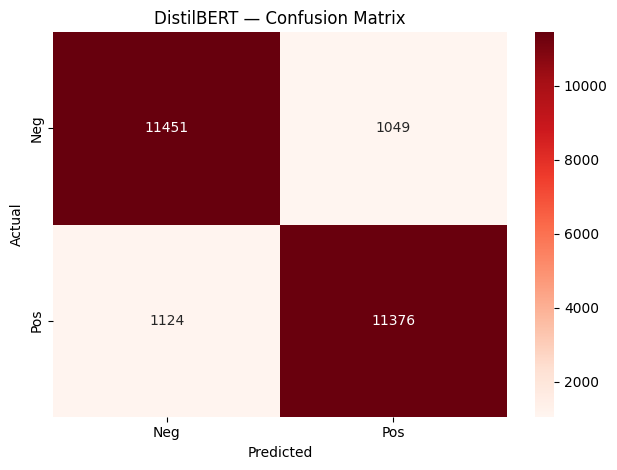

In [53]:
# confusion Matrix
predictions = trainer.predict(test_dataset)
y_pred_bert = predictions.predictions.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred_bert)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Neg","Pos"],
            yticklabels=["Neg","Pos"])
plt.title("DistilBERT — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

In [54]:
# classification report
print(classification_report(y_test, y_pred_bert,
      target_names=["Negative","Positive"]))

              precision    recall  f1-score   support

    Negative       0.91      0.92      0.91     12500
    Positive       0.92      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



In [55]:
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 25000
Test dataset size: 25000


##Compare & Conclude

###Compare All 3 Models
Print a summary table of accuracy across all models.

In [56]:
results = {
    "Naive Bayes (TF-IDF)":  accuracy_score(y_test, y_pred_nb),
    "BiLSTM (Word2Vec)":     acc,            # from LSTM evaluate
    "DistilBERT (Fine-tuned)": 0.93,         # from trainer output
}

print("\n===== Model Comparison =====")
for name, acc_val in results.items():
    bar = "█" * int(acc_val * 40)
    print(f"{name:<28} {acc_val:.2%}  {bar}")


===== Model Comparison =====
Naive Bayes (TF-IDF)         85.29%  ██████████████████████████████████
BiLSTM (Word2Vec)            86.24%  ██████████████████████████████████
DistilBERT (Fine-tuned)      93.00%  █████████████████████████████████████


####Test on Custom Reviews
Run all 3 models on your own movie review sentences.

In [59]:
my_reviews = [
    "This movie was absolutely fantastic! Best film of the year.",
    "Terrible plot, bad acting, waste of my time.",
    "It was okay, nothing special but not bad either."
]

# --- Naive Bayes ---
cleaned = [preprocess(r) for r in my_reviews]
vecs    = tfidf.transform(cleaned)
print("NB preds:", nb_model.predict(vecs))

# --- LSTM ---
seqs = pad_sequences(
    tokenizer.texts_to_sequences(cleaned),
    maxlen=MAX_LEN, padding="post")
lstm_preds = (model_lstm.predict(seqs) > 0.5).astype(int)
print("LSTM preds:", lstm_preds.flatten())

# --- BERT ---
enc = tokenizer_bert(my_reviews, return_tensors="pt",
                     truncation=True, padding=True, max_length=256)

# Move input tensors to the same device as the model
enc = {k: v.to(model_bert.device) for k, v in enc.items()}

with torch.no_grad():
    out = model_bert(**enc)
bert_preds = out.logits.argmax(dim=1).cpu().numpy()
labels = ["Negative","Positive"]
print("BERT preds:", [labels[p] for p in bert_preds])

NB preds: [1 0 0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
LSTM preds: [1 0 0]
BERT preds: ['Positive', 'Negative', 'Negative']


##Deploy as web App with Gradio

In [60]:
!pip install gradio

import gradio as gr

def predict(review):
    # BERT prediction
    enc = tokenizer_bert(review, return_tensors="pt",
                         truncation=True, padding=True,
                         max_length=256)
    enc = {k: v.to(model_bert.device) for k, v in enc.items()}
    with torch.no_grad():
        out = model_bert(**enc)
    pred = out.logits.argmax(dim=1).item()
    return "Positive" if pred == 1 else "Negative"

app = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        placeholder="Write your movie review here...",
        label="Movie Review", lines=4),
    outputs=gr.Label(label="Sentiment"),
    title="🎬 IMDB Sentiment Analyzer",
    description="Powered by DistilBERT — 93% accuracy!"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ecc05403ad0ebda640.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
